In [1]:
# Importando bibliotecas
import numpy as np
import matplotlib.pyplot as plt

# Representação do numeros
dados = np.zeros((5,3,10)) # Matriz para guardar os numeros

# Numero 0
dados[:,:,0] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 1
dados[:,:,1] = [[0.0, 1.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 1.0, 0.0],
                [0.0, 1.0, 0.0]]
# Numero 2
dados[:,:,2] = [[1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [1.0, 0.0, 0.0],
                [1.0, 1.0, 1.0]]
# Numero 3
dados[:,:,3] = [[1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 4
dados[:,:,4] = [[1.0, 0.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [0.0, 0.0, 1.0]]
# Numero 5
dados[:,:,5] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 0.0],
                [1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 6
dados[:,:,6] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 0.0],
                [1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 7
dados[:,:,7] = [[1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [0.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [0.0, 0.0, 1.0]]
# Numero 8
dados[:,:,8] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0]]
# Numero 9
dados[:,:,9] = [[1.0, 1.0, 1.0],
                [1.0, 0.0, 1.0],
                [1.0, 1.0, 1.0],
                [0.0, 0.0, 1.0],
                [0.0, 0.0, 1.0]]

# TESTE

In [24]:
# Organizando os dados

U = np.zeros((10,15)) #Guardar os valores
for i in range(10):
  U[i,:] = dados[:,:,i].flatten()
  # Adicionando as colunas de 1's
  UI = np.hstack((U,np.ones((10,1))))

#Vetor de saida par = 0 e impar = 1 classificação
Y = np.array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1]).reshape(-1,1) # forçar vetor coluna
print(Y)



[[0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]]


In [25]:
# Criando o neuronio

def neuronio(u,params):
  # Nucleo: Combinação linear
  x = u.dot(params)
  # Função de ativação: transformação ñ linear
  y = np.where(x>0,1,0)
  return y

# Chute iniciais dos parâmetros
theta_0 = np.ones((16,1))
theta_0[-1] = 7.5 # bias

#Predição com chute inicial
y_pred = neuronio(UI,theta_0)
print(y_pred)

# Erro inicial
E0 = y_pred - Y
print(E0)

[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]
[[1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]
 [1]
 [0]]


In [34]:
# Apredizagem
theta_j = theta_0.copy()
alpha = 1e-3 # Taxa de aprendizagem
n_epocas = 700
E = np.zeros((n_epocas,1))
n_dados = UI.shape[0] # Número de dados da matriz de entrada (numero de dados)
for i in range(n_epocas):
  Soma = 0.0
  for j in range(n_dados):
    # Calcular o erro
    e_j = (neuronio(UI[[j],:],theta_j) - Y[j])
    # Atualização do theta_j
    theta_j = theta_j - alpha*2*e_j*UI[[j],:].T
    # Guardando o Erro
    Soma = Soma + e_j**2
  # end for
  E[i] = Soma

# print(theta_j)
# plt.plot(E,'.-')

Parâmetros finais:
[[-0.782]
 [ 0.01 ]
 [-0.782]
 [-0.484]
 [ 1.   ]
 [-0.508]
 [-0.782]
 [-0.442]
 [-0.782]
 [-0.406]
 [ 1.   ]
 [-0.384]
 [-0.242]
 [-0.242]
 [-0.782]
 [ 5.718]]

=== RESULTADOS ===
Accuracy: 100.00%

=== DETALHES ===
Total de amostras: 10
Predições corretas: 10
Predições incorretas: 0


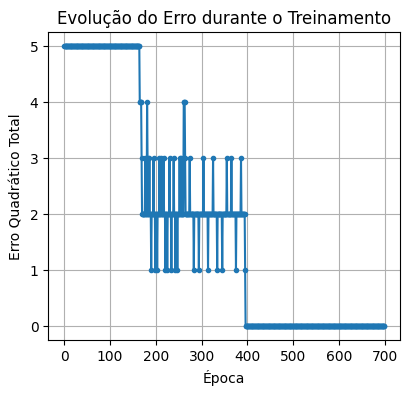

In [ ]:
print("Parâmetros finais:")
print(theta_j)

# Plotar evolução do erro
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(E, '.-')
plt.title('Evolução do Erro durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Erro Quadrático Total')
plt.grid(True)

# CALCULAR ACCURACY
y_pred = neuronio(UI, theta_j)
accuracy = np.mean(y_pred == Y) * 100

print(f"\n=== RESULTADOS ===")
print(f"Accuracy: {accuracy:.2f}%")

# Mostrar matriz de confusão simples
print(f"\n=== DETALHES ===")
print(f"Total de amostras: {len(Y)}")
print(f"Predições corretas: {np.sum(y_pred == Y)}")
print(f"Predições incorretas: {np.sum(y_pred != Y)}")



In [39]:
numeros = np.arange(100)
Y = np.array([0 if n % 2 == 0 else 1 for n in numeros])
# CALCULAR ACCURACY
y_pred = neuronio(UI, theta_j)
accuracy = np.mean(y_pred == Y) * 100

print(f"\n=== RESULTADOS ===")
print(f"Accuracy: {accuracy:.2f}%")

# Mostrar matriz de confusão simples
print(f"\n=== DETALHES ===")
print(f"Total de amostras: {len(Y)}")
print(f"Predições corretas: {np.sum(y_pred == Y)}")
print(f"Predições incorretas: {np.sum(y_pred != Y)}")


=== RESULTADOS ===
Accuracy: 50.00%

=== DETALHES ===
Total de amostras: 100
Predições corretas: 500
Predições incorretas: 500
